In [61]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler


In [46]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0,  0, 0, 1, 1, 1])

In [47]:
pos=y_train==1
neg=y_train==0

print(pos)
print(neg)

[False False False  True  True  True]
[ True  True  True False False False]


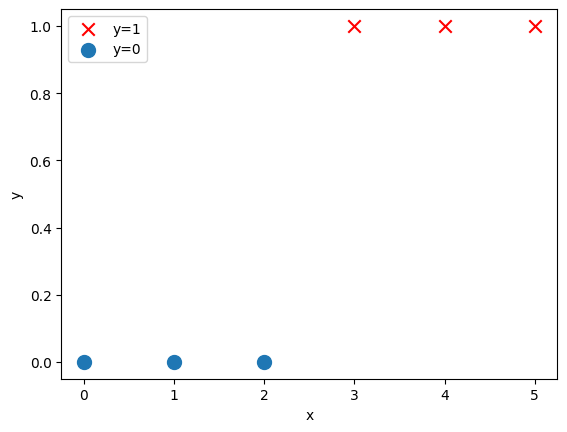

In [48]:
plt.scatter(x_train[pos],y_train[pos],marker='x',s=80,c='r',label="y=1")
plt.scatter(x_train[neg],y_train[neg],marker='o',s=100,label='y=0')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [49]:
model=SGDRegressor(max_iter=1000,eta0=0.1,learning_rate='constant')

In [67]:
# Always rebuild from scratch
X_train = x_train.reshape(-1, 1)
Y_train = y_train.copy()          # don't touch original y_train

model.fit(X_train, Y_train)
yp1 = model.predict(X_train)

# Create outlier version as separate new variables
X_train2 = np.append(X_train, [[10]], axis=0)
Y_train2 = np.append(Y_train, 1)

pos=Y_train2==1
neg=Y_train2==0




scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)

model2 = SGDRegressor(max_iter=1000, eta0=0.1, learning_rate='constant')
model2.fit(X_train2_scaled, Y_train2)
yp2 = model2.predict(X_train2_scaled)

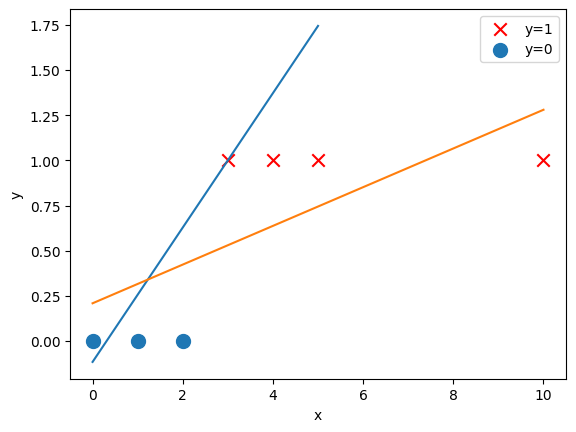

In [68]:
plt.scatter(X_train2[pos],Y_train2[pos],marker='x',s=80,c='r',label="y=1")
plt.scatter(X_train2[neg],Y_train2[neg],marker='o',s=100,label='y=0')
plt.plot(X_train,yp1)
plt.plot(X_train2,yp2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()